L = 2, N = 1, dim = 2
SIDEBAND = 1 -> f_drive_hz = 1098.10 Hz (detuning = -2 Hz)
static depth V0 = 7.5 Er -> J(V0) = 43.3228 Hz


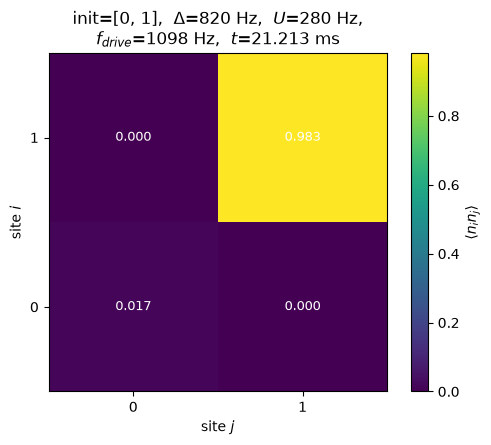

In [21]:
# This code will plot the two-particle correlations for a specific evolution sequence

import itertools
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

# =============================================================
# ============  USER-CHANGEABLE VALUES  =======================
# =============================================================
state_init = [0, 1]          # initial Fock state
state_init   = list(state_init)
L = len(state_init)
N = sum(state_init)

Delta_hz   = 820.0           # tilt per site (Hz)
U_hz       = 280.0           # on-site interaction (Hz)

SIDEBAND = 1        # toggles which sideband / carrier to drive

V0 = .75 * 10.0       # static lattice depth (Er). 0.75 and 0.8 are scaling factors I put in by hand to recreate our tunneling parameters.
alpha = [0.2]                # depth modulation amplitude(s) of the lattice. I later define V_to_J which provides deltaJ amplitude.

# scan / fit controls
N_PERIODS_PER_RABI = 100     # sets time-trace length (3x this many drive periods)
TIME_SAMPLES_PER_PERIOD = 20

PULSE_SPAN_HZ            = 100.0   # +/- frequency range for the profile scan
PULSE_N_POINTS           = 31
PULSE_SAMPLES_PER_PERIOD = 40
# =============================================================
# ==========  END USER-CHANGEABLE VALUES  =====================
# =============================================================

# -----------------------------
# Physical parameters in angular units
# -----------------------------
# =============================================================
# LATTICE DEPTH -> TUNNELING CONVERTER
# =============================================================
J_OUTPUT_UNITS = "Hz"
E_R_HZ = 1.0
twopi  = 2.0 * np.pi
alpha = np.atleast_1d(np.asarray(alpha, dtype=float))
U     = twopi * U_hz
Delta = twopi * Delta_hz

# Found this by fitting lattice depth to J for the wannier functions which also agrees with data.
def V_to_J(V):
    V = np.asarray(V, dtype=float)
    a = 284.4; b = -0.2922; c = 30.69; d = -0.1304   # Er in, Hz out
    return a * np.exp(b * V) + c * np.exp(d * V)

# Get angular frequencies
def J_angular(V):
    Jval = V_to_J(V)
    if J_OUTPUT_UNITS == "Hz":        return twopi * Jval
    elif J_OUTPUT_UNITS == "angular": return Jval
    elif J_OUTPUT_UNITS == "Er":      return twopi * E_R_HZ * Jval
    else: raise ValueError("J_OUTPUT_UNITS must be 'Hz', 'angular', or 'Er'")

def J_mean_0(om, n_sub=10000):
    """Time-averaged J (Hz) over one Floquet period of the drive `om`."""
    T = 1.0 / (om.min() / twopi)
    t = np.linspace(0.0, T, n_sub, endpoint=False)
    Vt = V0 * (1.0 + np.sum(alpha[:, None] * np.cos(np.outer(om, t)), axis=0))
    return V_to_J(Vt).mean()

if SIDEBAND > 0:
    det_hz = -0.77 * J_mean_0(omega_drive)**2 / Delta_hz
elif SIDEBAND < 0:
    det_hz = 3.18 * J_mean_0(omega_drive)**2 / Delta_hz
else:
    det_hz = 2.30 * J_mean_0(omega_drive)**2 / Delta_hz

# --- derive drive frequency and target state from the toggle -----------------
if SIDEBAND > 0:
    f_drive_hz = Delta_hz + U_hz + det_hz
elif SIDEBAND < 0:
    f_drive_hz = Delta_hz - U_hz + det_hz
else:
    f_drive_hz = Delta_hz

det   = twopi * det_hz
# nominal drive (single tone at the chosen sideband)
omega_drive = twopi * np.atleast_1d(np.asarray([f_drive_hz], dtype=float))
if alpha.shape != omega_drive.shape:
    raise ValueError("alpha and the drive-tone list must have the same length.")

# =============================================================
# Fixed-N basis and Hamiltonian
# =============================================================
def generate_basis(L, N):
    return [tuple(occ) for occ in itertools.product(range(N + 1), repeat=L)
            if sum(occ) == N]

basis = generate_basis(L, N)
index = {s: i for i, s in enumerate(basis)}
dim   = len(basis)

print("L = %d, N = %d, dim = %d" % (L, N, dim))
print("SIDEBAND = %s -> f_drive_hz = %.2f Hz (detuning = %.0f Hz)" % (SIDEBAND, f_drive_hz, det_hz))
print("static depth V0 = %.4g Er -> J(V0) = %.4f Hz" % (V0, J_angular(V0)/twopi))

def build_diag():
    H = np.zeros((dim, dim), dtype=complex)
    for a, state in enumerate(basis):
        n = np.array(state)
        H[a, a] = 0.5 * U * np.sum(n*(n-1)) - Delta * np.sum(np.arange(L)*n)
    return H

def build_hop_unit():
    H = np.zeros((dim, dim), dtype=complex)
    for a, state in enumerate(basis):
        n = np.array(state)
        for j in range(L-1):
            if n[j] > 0:
                new = n.copy(); amp = np.sqrt(n[j])*np.sqrt(n[j+1]+1)
                new[j]-=1; new[j+1]+=1
                H[index[tuple(new)], a] += -amp
            if n[j+1] > 0:
                new = n.copy(); amp = np.sqrt(n[j+1])*np.sqrt(n[j]+1)
                new[j+1]-=1; new[j]+=1
                H[index[tuple(new)], a] += -amp
    return H

H_diag     = build_diag()
H_hop_unit = build_hop_unit()

# -----------------------------
# State and projector
# -----------------------------
psi0 = np.zeros(dim, dtype=complex)
psi0[index[tuple(state_init)]] = 1.0
P_target = np.zeros((dim, dim), dtype=complex)

# =============================================================
# Evolution and fit helpers
# =============================================================
def V_of_t(t, om):
    return V0 * (1.0 + np.sum(alpha * np.cos(om * t)))

def evolve(n_periods, samples_per_period, om, t_end=None):
    """Evolve under the drive at angular frequency vector `om`. If t_end is given
    it overrides n_periods (used for fixed-duration pulses)."""
    T_ref_local = 1.0 / (om.min() / twopi)
    if t_end is None:
        t_end = n_periods * T_ref_local
        ntimes = n_periods * samples_per_period + 1
    else:
        n_per = max(1, int(round(t_end / T_ref_local)))
        ntimes = n_per * samples_per_period + 1
    def rhs(t, psi):
        Jt = J_angular(V_of_t(t, om))
        return -1j * (H_diag + Jt * H_hop_unit).dot(psi)
    times = np.linspace(0.0, t_end, ntimes)
    sol = solve_ivp(rhs, (0.0, t_end), psi0, t_eval=times,
                    rtol=1e-9, atol=1e-9, method="RK45")
    return times, sol.y.T

# =============================================================
# Two-particle correlation matrix  G_ij = <n_i n_j>
# =============================================================
# Precompute occupation arrays for each basis state
n_basis = np.array([list(s) for s in basis], dtype=float)   # shape (dim, L)

def build_correlation_matrix(t_evolve):
    """Evolve psi0 to time t_evolve (seconds) and return the two-particle
    correlation matrix G_ij = <n_i n_j> (shape L x L)."""
    # Evolve to the requested time using the same drive as evolve()
    T_ref_local = 1.0 / (omega_drive.min() / twopi)
    n_per = max(1, int(round(t_evolve / T_ref_local)))
    ntimes = n_per * TIME_SAMPLES_PER_PERIOD + 1
    times = np.linspace(0.0, t_evolve, ntimes)

    def rhs(t, psi):
        Jt = J_angular(V_of_t(t, omega_drive))
        return -1j * (H_diag + Jt * H_hop_unit).dot(psi)

    sol = solve_ivp(rhs, (0.0, t_evolve), psi0, t_eval=times,
                    rtol=1e-9, atol=1e-9, method="RK45")
    psi_t = sol.y.T[-1]                     # final state
    prob = np.abs(psi_t)**2                 # population in each Fock state

    # G_ij = sum_state prob(state) * n_i * n_j
    G = np.zeros((L, L), dtype=float)
    for k in range(dim):
        G += prob[k] * np.outer(n_basis[k], n_basis[k])
    return G

# =============================================================
# Plot the correlation matrix
# =============================================================
t_evolve = 0.03/np.sqrt(2)                              # evolution time in seconds (change as needed)

G = build_correlation_matrix(t_evolve)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(G, origin="lower", cmap="viridis")
ax.set_xticks(range(L)); ax.set_yticks(range(L))
ax.set_xlabel("site $j$"); ax.set_ylabel("site $i$")
fig.colorbar(im, ax=ax, label=r"$\langle n_i n_j \rangle$")

# annotate cell values
for i in range(L):
    for j in range(L):
        ax.text(j, i, "%.3f" % G[i, j], ha="center", va="center",
                color="w", fontsize=9)

ax.set_title("init=%s,  $\\Delta$=%.0f Hz,  $U$=%.0f Hz,\n"
             "$f_{drive}$=%.0f Hz,  $t$=%.3f ms"
             % (state_init, Delta_hz, U_hz, f_drive_hz, t_evolve * 1e3))
plt.tight_layout()
plt.show()